# The bellows element

A bellows is a corrugated section of beam pipe: it lets a beam line expand,
contract and flex without breaking vacuum. Electromagnetically it is a train of
small cavities coupled to the bore, so it shifts the frequency of a nearby
resonance and adds impedance of its own.

`Bellows` is a device in its own right — it meshes, solves and tunes like any
other geometry — and it is meant to be concatenated into a beam line. This
notebook covers the element alone; see
[Assembling a beam line](beam_line_assembly.ipynb) for putting one in a line.

This notebook is live: every figure below is produced by running `cavsim2d`.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

from cavsim2d import Bellows
from cavsim2d.utils.style import apply_style, WARM

apply_style()          # the house publication style
workspace = tempfile.mkdtemp()

## 1. The parameterisation

One convolution is a root flat, a flank, a crest flat and a flank back down,
repeated `N_conv` times along the bore. Every corner is rounded.

| parameter | meaning |
| --- | --- |
| `Ri` | bore (root) radius |
| `A` | convolution depth, so the crest sits at `Ri + A` |
| `L_p` | period of one convolution |
| `N_conv` | number of convolutions |
| `R_root`, `R_crest` | corner radii at the root and at the crest — they may differ |
| `crest_fraction` | share of the period's flat length given to the crest (default 0.5) |
| `flank_angle` | flank angle from the axis, in degrees (default 90, i.e. vertical) |
| `L_bp` | straight pipe carried at each end (default 0) |

All lengths are in millimetres, as everywhere else in `cavsim2d`.

![Bellows parameters](../../_static/beamline_bellows_nomenclature.png)

In [2]:
bel = Bellows(Ri=35.0, A=8.0, L_p=6.0, N_conv=10,
              R_root=1.2, R_crest=1.2, L_bp=10.0)

print(f"corrugated length : {bel.length:.1f} mm")
print(f"crest radius      : {bel.parameters['Ri'] + bel.parameters['A']:.1f} mm")
bel.parameters

corrugated length : 60.0 mm
crest radius      : 43.0 mm


{'Ri': 35.0,
 'A': 8.0,
 'L_p': 6.0,
 'R_root': 1.2,
 'R_crest': 1.2,
 'crest_fraction': 0.5,
 'flank_angle': 90.0,
 'L_bp': 10.0}

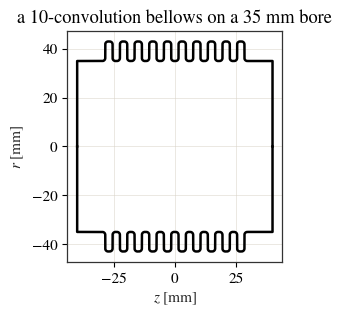

In [3]:
ax = bel.plot('geometry', mirror=True, show=False)
ax.set_title('a 10-convolution bellows on a 35 mm bore')
plt.show()

## 2. Rounded corners, and when they do not fit

The corner radii are real geometry, not cosmetic: they set the peak surface
field and they are what a multipacting or impedance study is sensitive to. Each
corner is a circular arc inscribed in the corner, tangent to both walls, so the
wall has no kinks anywhere.

That rounding costs room. Three conditions have to hold, and `Bellows` checks
them when you build it — you get a named constraint immediately, rather than a
failure later when something tries to mesh it:

* both root corners must fit on the root flat,
* both crest corners must fit on the crest flat,
* the root and crest corners sharing a flank must both fit on it.

In [4]:
nominal = dict(Ri=35.0, A=8.0, L_p=6.0, N_conv=10, R_root=1.2, R_crest=1.2)

for change in (dict(R_crest=2.0), dict(R_root=2.5), dict(A=2.0)):
    try:
        Bellows(**{**nominal, **change})
    except ValueError as err:
        print(f"{str(change):<24} -> {err}\n")

{'R_crest': 2.0}         -> crest corners do not fit: 2 * R_crest * tan(flank_angle/2) = 4 mm exceeds the 3 mm crest flat. Reduce R_crest below 1.5 mm, or lengthen L_p.

{'R_root': 2.5}          -> root corners do not fit: 2 * R_root * tan(flank_angle/2) = 5 mm exceeds the 3 mm root flat. Reduce R_root below 1.5 mm, or lengthen L_p.

{'A': 2.0}               -> the root and crest corners do not both fit on the 2 mm flank: they need 2.4 mm. Reduce R_root / R_crest, or deepen the convolution (A).



### The deep-convolution limit

For a hydroformed bellows the crest is very nearly a semicircle: the corner
radius reaches a quarter of the period and the flats vanish entirely. That is
the *nominal* shape of a real bellows, not an awkward edge case, so it is
handled directly — the flats simply disappear and the wall runs arc to arc.

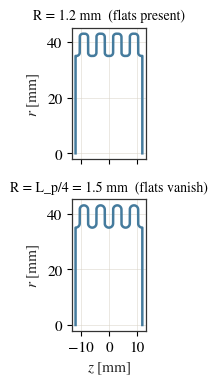

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ax, R, title in zip(axes, (1.2, 1.5),
                        ('R = 1.2 mm  (flats present)',
                         'R = L_p/4 = 1.5 mm  (flats vanish)')):
    b = Bellows(Ri=35.0, A=8.0, L_p=6.0, N_conv=4, R_root=R, R_crest=R)
    b.plot('geometry', ax=ax, color=WARM[0], show=False)
    ax.set_title(title, fontsize=10)
axes[0].set_xlabel('')
plt.tight_layout()
plt.show()

### Leaning flanks

Some vendor drawings have a flank that is a few degrees off vertical. That is
one parameter, not a different geometry: `flank_angle` tilts the flank and the
corners follow.

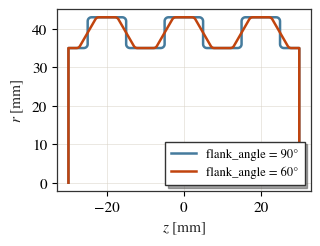

In [6]:
fig, ax = plt.subplots(figsize=(10, 2.6))
for angle, colour in zip((90.0, 60.0), WARM[:2]):
    b = Bellows(Ri=35.0, A=8.0, L_p=20.0, N_conv=3,
                R_root=1.0, R_crest=1.0, flank_angle=angle)
    b.plot('geometry', ax=ax, color=colour, show=False,
           label=f'flank_angle = {angle:.0f}°')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Solving a bellows

A bellows on its own is an open pipe, so close its ends to get something with a
discrete spectrum. Here we short both ends and watch the fundamental as the
convolutions get deeper: the corrugation adds volume off the bore, so the
resonance falls well below the smooth-pipe value.

In [7]:
depths = [5.0, 10.0, 15.0, 20.0]
freqs = []

for A in depths:
    b = Bellows(Ri=35.0, A=A, L_p=8.0, N_conv=10,
                R_root=1.5, R_crest=1.5, name=f'bellows_A{A:.0f}')
    b.set_workspace(os.path.join(workspace, b.name))
    b.eigenmode.run({'polarisation': 'monopole', 'n_modes': 2,
                     'boundary_conditions': 'ee',      # shorted at both ends
                     'mesh_config': {'h': 2, 'p': 2}})
    freqs.append(b.eigenmode.qois['freq [MHz]'])
    print(f"A = {A:5.1f} mm  ->  f = {freqs[-1]:9.3f} MHz")

A =   5.0 mm  ->  f =  3060.579 MHz


A =  10.0 mm  ->  f =  2858.327 MHz


A =  15.0 mm  ->  f =  2656.856 MHz


A =  20.0 mm  ->  f =  2454.625 MHz


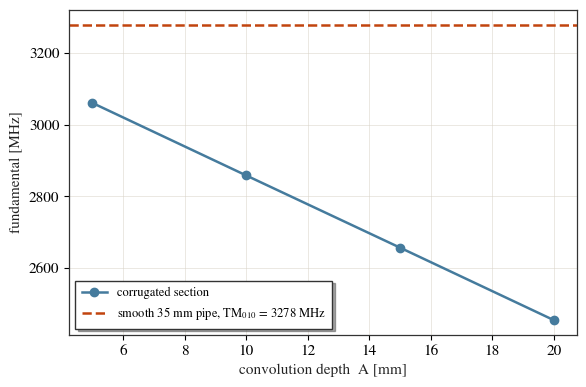

In [8]:
c0 = 299792458.0
f_smooth = c0 * 2.404825557695773 / (2 * np.pi * 35.0e-3) * 1e-6

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(depths, freqs, 'o-', color=WARM[0], label='corrugated section')
ax.axhline(f_smooth, color=WARM[1], ls='--',
           label=f'smooth 35 mm pipe, TM$_{{010}}$ = {f_smooth:.0f} MHz')
ax.set_xlabel('convolution depth  A [mm]')
ax.set_ylabel('fundamental [MHz]')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Wakefield

The eigenmode above needed the ends shorted. For impedance the structure is left
open and a bunch is driven through it: `wakefield.run` writes an ABCI deck from
the same profile.

ABCI will not run a structure without a beam pipe at each end, so one is always
added. Left to itself it adds three times the device's own length, which is
fine for a single run and wrong for a sweep: the pipe would grow with the
bellows and each point would be a different structure. `beampipe_length` (metres)
pins it instead, so only the thing under study changes.

The corrugation is a train of small cavities coupled to the bore, so it takes
energy from the bunch and kicks it transversely.

In [9]:
bel = Bellows(Ri=35.0, A=8.0, L_p=6.0, N_conv=10,
              R_root=1.2, R_crest=1.2, name='bellows_wake')
bel.set_workspace(os.path.join(workspace, 'bellows_wake'))
bel.wakefield.run({'MROT': 2, 'wakelength': 20, 'bunch_length': 25,
                   'beampipe_length': 0.15})          # 150 mm each end
bel.wakefield.qois

{'|k_loss| [V/pC]': 0.001288, '|k_kick| [V/pC/m]': 1.71}

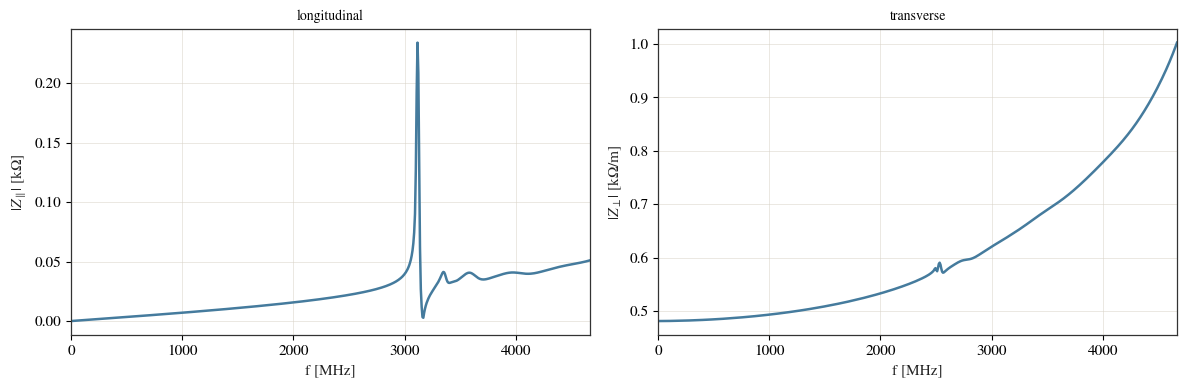

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
bel.wakefield.plot_impedance('longitudinal', ax=a1, show=False)
bel.wakefield.plot_impedance('transverse', ax=a2, show=False)
a1.set_title('longitudinal', fontsize=10)
a2.set_title('transverse', fontsize=10)
plt.tight_layout()
plt.show()

### The loss factor grows with the number of convolutions

Each convolution contributes, so a longer bellows costs more. This is the
number to watch when a mechanical requirement asks for more travel.

In [11]:
n_convs = [4, 8, 12]
k_loss = []

for n in n_convs:
    b = Bellows(Ri=35.0, A=8.0, L_p=6.0, N_conv=n,
                R_root=1.2, R_crest=1.2, name=f'bellows_n{n}')
    b.set_workspace(os.path.join(workspace, b.name))
    b.wakefield.run({'MROT': 0, 'wakelength': 10, 'bunch_length': 25,
                     'beampipe_length': 0.15})        # same pipe at every point
    k_loss.append(b.wakefield.qois['|k_loss| [V/pC]'])
    print(f'N_conv = {n:3d}   k_loss = {k_loss[-1]:.6f} V/pC')

N_conv =   4   k_loss = 0.000415 V/pC


N_conv =   8   k_loss = 0.001009 V/pC


N_conv =  12   k_loss = 0.001438 V/pC


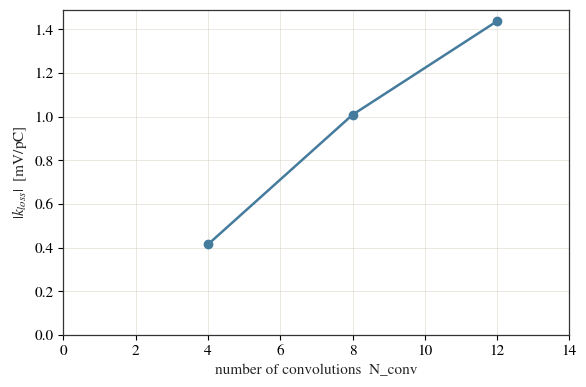

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_convs, np.array(k_loss) * 1e3, 'o-', color=WARM[0])
ax.set_xlabel('number of convolutions  N_conv')
ax.set_ylabel(r'$|k_{loss}|$  [mV/pC]')
ax.set_xlim(0, max(n_convs) + 2)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

### Check the mesh before trusting a bellows loss factor

ABCI solves on a uniform mesh set by `DDR` / `DDZ`, and a bellows has features
far smaller than a cavity: here the corner radius is 1.2 mm against a default
1.25 mm cell, so the rounding is crossed by about one cell. Refining the mesh
moves the answer, and not monotonically.

In [13]:
for ddr in (2.5e-3, 1.25e-3, 0.8e-3, 0.5e-3, 0.3e-3):
    b = Bellows(Ri=35.0, A=8.0, L_p=6.0, N_conv=8,
                R_root=1.2, R_crest=1.2, name=f'bellows_m{ddr:.0e}')
    b.set_workspace(os.path.join(workspace, b.name))
    b.wakefield.run({'MROT': 0, 'wakelength': 10, 'bunch_length': 25,
                     'beampipe_length': 0.15,
                     'mesh_config': {'DDR': ddr, 'DDZ': ddr}})
    cells = 1.2 / (ddr * 1e3)
    print(f'DDR = {ddr * 1e3:4.2f} mm  ({cells:4.1f} cells per fillet)   '
          f"k_loss = {b.wakefield.qois['|k_loss| [V/pC]']:.6f} V/pC")

DDR = 2.50 mm  ( 0.5 cells per fillet)   k_loss = 0.001281 V/pC


DDR = 1.25 mm  ( 1.0 cells per fillet)   k_loss = 0.001009 V/pC


DDR = 0.80 mm  ( 1.5 cells per fillet)   k_loss = 0.001037 V/pC


DDR = 0.50 mm  ( 2.4 cells per fillet)   k_loss = 0.001176 V/pC


DDR = 0.30 mm  ( 4.0 cells per fillet)   k_loss = 0.001121 V/pC


The spread across those meshes is about a quarter of the value, and it does not
settle monotonically, so a bellows loss factor quoted from a single run at the
default mesh is not a converged number. Run the sweep
and quote the trend, or refine until it settles. A geometry without small
features — a taper, say — converges at the default mesh instead; see
[The taper element](taper.ipynb).

## What to take away

* `Bellows` is parameterised the way a drawing is — depth, period, corner radii —
  and it rejects a set of radii that cannot physically fit, at the moment you
  build it.
* The rounded corners are exact arcs, so every analysis sees the same wall.
* Deeper convolutions pull the resonance down, steeply.
* The loss factor grows with the number of convolutions, and it is mesh
  sensitive: the corner radii are smaller than a default ABCI cell, so check
  convergence before quoting a number.

Next: [Assembling a beam line](beam_line_assembly.ipynb) puts a bellows either
side of a cavity and solves the whole line at once.